<a href="https://colab.research.google.com/github/anshikabansal25/ML-Lab-Assignments/blob/main/Anshika_102203914.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

file_path = '/Fuel_cell_performance_data-Full.csv'
data = pd.read_csv(file_path)

X = data.drop(columns=['Target1', 'Target2', 'Target3', 'Target4', 'Target5'])
y = data['Target5']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Original Feature Values (First 5 Rows):")
print(X.head(), "\n")
print("Scaled Feature Values (First 5 Rows):")
print(X_scaled_df.head(), "\n")


Original Feature Values (First 5 Rows):
     F1    F2    F3     F4      F5    F6     F7     F8   F9   F10      F11  \
0  52.9  1.33  49.1  37.13  129.43  35.0  0.281  112.7  207  0.55   98.971   
1  87.6  2.12  48.8  42.10  171.07  37.6  0.153  157.4  188  0.86  101.179   
2  73.3  2.72  93.8  20.11  163.69  44.3  0.367  348.7  270  1.87   98.919   
3  65.6  2.58  48.1  35.11   63.37  32.5  0.279  321.2  322  1.75  101.560   
4  39.6  2.58  49.3  32.93   63.40  47.0  0.149  205.6  203  1.55   98.148   

    F12   F13   F14   F15  
0  2.87  1362  15.9   429  
1  2.34  5130  26.1  1819  
2  2.13  7811  16.7  1763  
3  2.91  1641  32.1   203  
4  1.93  7648  27.5   276   

Scaled Feature Values (First 5 Rows):
         F1        F2        F3        F4        F5        F6        F7  \
0 -0.224390 -0.686275 -0.446870  0.393376  0.139555 -0.189691  0.231648   
1  0.904065  0.088235 -0.455604  0.644672  0.665446  0.024742 -0.603589   
2  0.439024  0.676471  0.854440 -0.467198  0.572240  0.577

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR (RBF Kernel)": SVR(kernel='rbf'),
    "SVR (Sigmoid Kernel)": SVR(kernel='sigmoid'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} - MSE: {mse:.2f}, R2: {r2:.3f}\n")

Training Linear Regression...
Linear Regression - MSE: 622.36, R2: 0.694

Training Random Forest...
Random Forest - MSE: 456.15, R2: 0.776

Training Gradient Boosting...
Gradient Boosting - MSE: 463.38, R2: 0.772

Training SVR (RBF Kernel)...
SVR (RBF Kernel) - MSE: 1557.81, R2: 0.235

Training SVR (Sigmoid Kernel)...
SVR (Sigmoid Kernel) - MSE: 1038.04, R2: 0.490

Training Decision Tree...
Decision Tree - MSE: 818.86, R2: 0.598

Training K-Nearest Neighbors...
K-Nearest Neighbors - MSE: 988.89, R2: 0.514



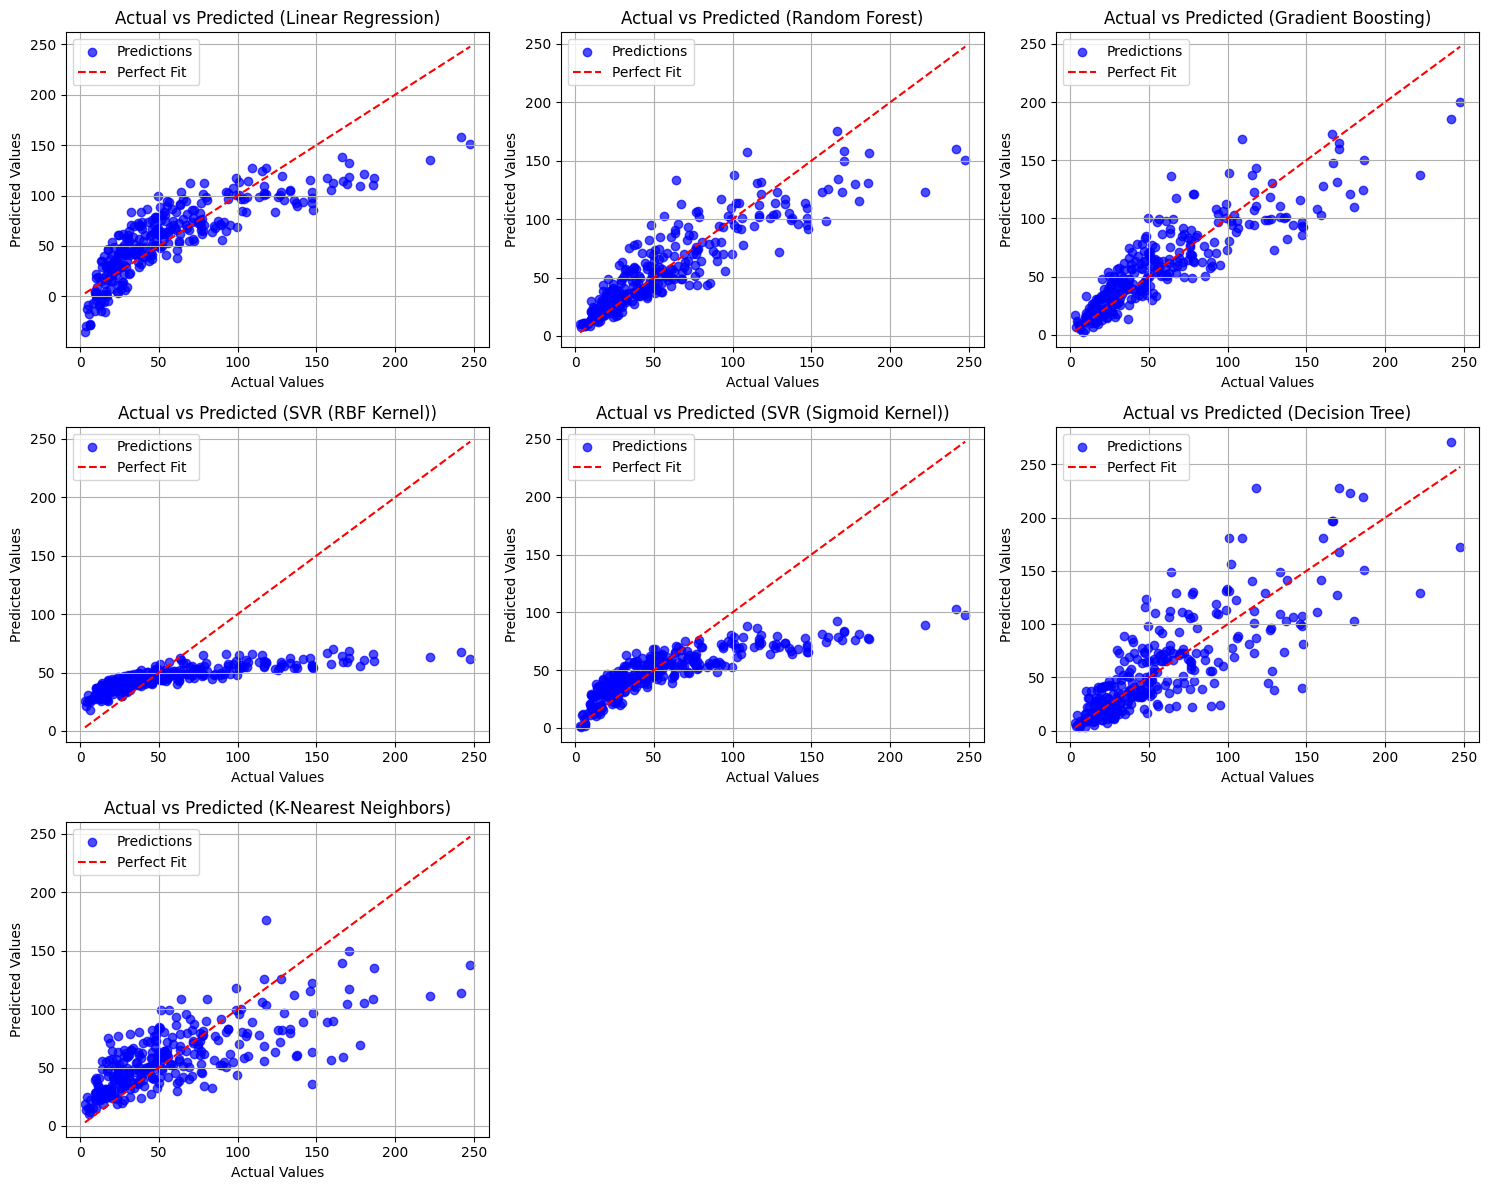

In [7]:
plt.figure(figsize=(15, 12))
for i, (name, y_pred) in enumerate(predictions.items(), start=1):
    plt.subplot(3, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.7, label="Predictions", color="blue")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label="Perfect Fit")
    plt.title(f"Actual vs Predicted ({name})")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
print("Summary of Results:")
best_model_name = None
best_r2 = float('-inf')

for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  - Mean Squared Error (MSE): {metrics['MSE']:.2f}")
    print(f"  - Coefficient of Determination (R²): {metrics['R2']:.3f}")
    if metrics['R2'] > best_r2:
        best_r2 = metrics['R2']
        best_model_name = model_name

print("\nBest Performing Model:")
print(f"{best_model_name} with R² = {best_r2:.3f}")

Summary of Results:
Linear Regression:
  - Mean Squared Error (MSE): 622.36
  - Coefficient of Determination (R²): 0.694
Random Forest:
  - Mean Squared Error (MSE): 456.15
  - Coefficient of Determination (R²): 0.776
Gradient Boosting:
  - Mean Squared Error (MSE): 463.38
  - Coefficient of Determination (R²): 0.772
SVR (RBF Kernel):
  - Mean Squared Error (MSE): 1557.81
  - Coefficient of Determination (R²): 0.235
SVR (Sigmoid Kernel):
  - Mean Squared Error (MSE): 1038.04
  - Coefficient of Determination (R²): 0.490
Decision Tree:
  - Mean Squared Error (MSE): 818.86
  - Coefficient of Determination (R²): 0.598
K-Nearest Neighbors:
  - Mean Squared Error (MSE): 988.89
  - Coefficient of Determination (R²): 0.514

Best Performing Model:
Random Forest with R² = 0.776
